
DATA TRAINING
Luas (m²)       Harga (juta Rp)     
--------------------------------------------------
45              400                 
60              520                 
75              650                 
90              750                 
100             850                 
120             1000                
150             1250                
180             1500                
200             1700                
250             2100                
HASIL PERHITUNGAN KOEFISIEN REGRESI
Intercept (a) = 15.76
Slope (b)     = 8.32
Persamaan: y = 15.76 + 8.32x

Koefisien Determinasi (R²) = 0.9995
Akurasi model: 99.95%

PREDIKSI HARGA RUMAH BARU
Luas 80 m² → Prediksi harga: Rp 681.11 juta
Luas 130 m² → Prediksi harga: Rp 1096.95 juta
Luas 220 m² → Prediksi harga: Rp 1845.47 juta


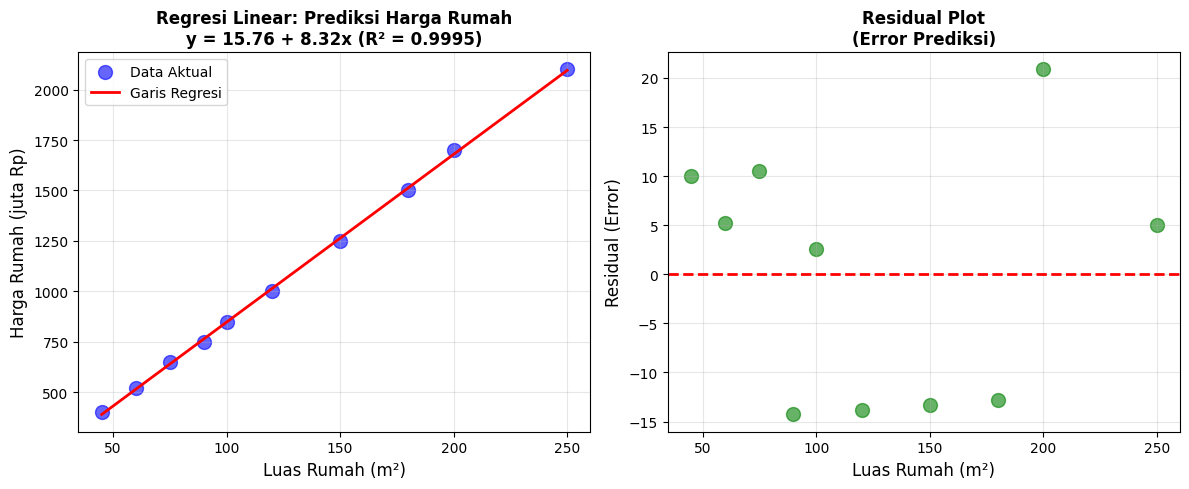


KESIMPULAN
Model regresi linear berhasil dibuat dengan R² = 0.9995
Setiap penambahan 1 m² luas rumah meningkatkan harga Rp 8.32 juta
Harga dasar rumah (intercept) adalah Rp 15.76 juta


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ========================================
# REGRESI LINEAR SEDERHANA
# Prediksi Harga Rumah Berdasarkan Luas
# ========================================

class RegresiLinear:
    """
    Implementasi Regresi Linear menggunakan Metode Least Squares
    Formula: y = a + bx
    dimana:
    - b (slope) = (n*Σxy - Σx*Σy) / (n*Σx² - (Σx)²)
    - a (intercept) = (Σy - b*Σx) / n
    """

    def __init__(self):
        self.a = 0  # intercept
        self.b = 0  # slope

    def fit(self, x, y):
        """
        Menghitung koefisien regresi a dan b
        """
        n = len(x)

        # Hitung sum yang diperlukan
        sum_x = np.sum(x)
        sum_y = np.sum(y)
        sum_xy = np.sum(x * y)
        sum_x2 = np.sum(x ** 2)

        # Hitung slope (b)
        self.b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)

        # Hitung intercept (a)
        self.a = (sum_y - self.b * sum_x) / n

        print("=" * 50)
        print("HASIL PERHITUNGAN KOEFISIEN REGRESI")
        print("=" * 50)
        print(f"Intercept (a) = {self.a:.2f}")
        print(f"Slope (b)     = {self.b:.2f}")
        print(f"Persamaan: y = {self.a:.2f} + {self.b:.2f}x")
        print("=" * 50)

    def predict(self, x):
        """
        Prediksi nilai y berdasarkan x
        """
        return self.a + self.b * x

    def r_squared(self, x, y):
        """
        Menghitung koefisien determinasi (R²)
        R² = 1 - (SS_res / SS_tot)
        """
        y_pred = self.predict(x)
        ss_res = np.sum((y - y_pred) ** 2)  # Sum of squares residual
        ss_tot = np.sum((y - np.mean(y)) ** 2)  # Total sum of squares
        r2 = 1 - (ss_res / ss_tot)

        print(f"\nKoefisien Determinasi (R²) = {r2:.4f}")
        print(f"Akurasi model: {r2*100:.2f}%")
        return r2


# ========================================
# DATA: Luas Rumah (m²) vs Harga (juta Rp)
# ========================================

# Data luas rumah dalam m²
luas_rumah = np.array([45, 60, 75, 90, 100, 120, 150, 180, 200, 250])

# Data harga rumah dalam juta rupiah
harga_rumah = np.array([400, 520, 650, 750, 850, 1000, 1250, 1500, 1700, 2100])

print("\n" + "=" * 50)
print("DATA TRAINING")
print("=" * 50)
print(f"{'Luas (m²)':<15} {'Harga (juta Rp)':<20}")
print("-" * 50)
for i in range(len(luas_rumah)):
    print(f"{luas_rumah[i]:<15} {harga_rumah[i]:<20}")
print("=" * 50)

# ========================================
# TRAINING MODEL
# ========================================

model = RegresiLinear()
model.fit(luas_rumah, harga_rumah)
r2 = model.r_squared(luas_rumah, harga_rumah)

# ========================================
# PREDIKSI HARGA RUMAH BARU
# ========================================

print("\n" + "=" * 50)
print("PREDIKSI HARGA RUMAH BARU")
print("=" * 50)

# Contoh prediksi untuk rumah dengan luas berbeda
luas_baru = [80, 130, 220]

for luas in luas_baru:
    harga_prediksi = model.predict(luas)
    print(f"Luas {luas} m² → Prediksi harga: Rp {harga_prediksi:.2f} juta")

# ========================================
# VISUALISASI HASIL
# ========================================

plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot + garis regresi
plt.subplot(1, 2, 1)
plt.scatter(luas_rumah, harga_rumah, color='blue', s=100, alpha=0.6, label='Data Aktual')
plt.plot(luas_rumah, model.predict(luas_rumah), color='red', linewidth=2, label='Garis Regresi')
plt.xlabel('Luas Rumah (m²)', fontsize=12)
plt.ylabel('Harga Rumah (juta Rp)', fontsize=12)
plt.title(f'Regresi Linear: Prediksi Harga Rumah\ny = {model.a:.2f} + {model.b:.2f}x (R² = {r2:.4f})',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals = harga_rumah - model.predict(luas_rumah)
plt.scatter(luas_rumah, residuals, color='green', s=100, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Luas Rumah (m²)', fontsize=12)
plt.ylabel('Residual (Error)', fontsize=12)
plt.title('Residual Plot\n(Error Prediksi)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("KESIMPULAN")
print("=" * 50)
print(f"Model regresi linear berhasil dibuat dengan R² = {r2:.4f}")
print(f"Setiap penambahan 1 m² luas rumah meningkatkan harga Rp {model.b:.2f} juta")
print(f"Harga dasar rumah (intercept) adalah Rp {model.a:.2f} juta")
print("=" * 50)